### Imports & GPU check

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from tensorflow import keras
from tensorflow.keras import layers

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Part I: Density Estimation using RealNVP

### Dataset


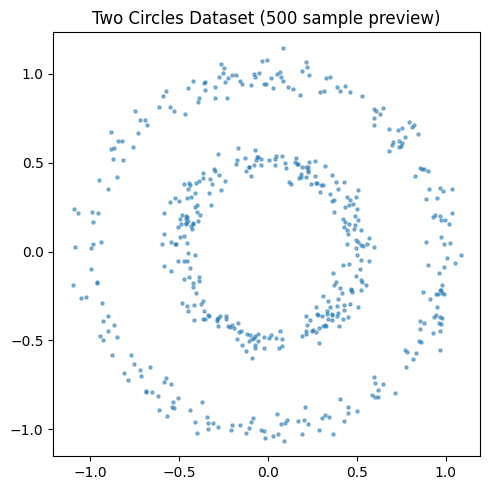

In [2]:
TOTAL_SAMPLES = 30_000
FACTOR        = 0.5
NOISE         = 0.05

X, _ = make_circles(n_samples=TOTAL_SAMPLES, factor=FACTOR, noise=NOISE)
X = X.astype("float32")

# Quick look
plt.figure(figsize=(5, 5))
plt.scatter(X[:500, 0], X[:500, 1], s=5, alpha=0.5)
plt.title("Two Circles Dataset (500 sample preview)")
plt.axis("equal"); plt.tight_layout(); plt.show()

## Task 1 – Modifications from original Keras RealNVP example

- Dataset changed to make_circles (30,000 samples, factor=0.5, noise=0.05)
- Added train/val split and tf.data pipeline
- Refactored into build_and_train() and plot_density() helpers
- Extended for epoch and coupling layer ablation studies (Tasks 2 & 3)## Task 1 – Modifications from original Keras RealNVP example
- Dataset changed to make_circles (30,000 samples, factor=0.5, noise=0.05)
- Added train/val split and tf.data pipeline
- Refactored into build_and_train() and plot_density() helpers
- Extended for epoch and coupling layer ablation studies (Tasks 2 & 3)

### Pipeline

In [3]:
BATCH_SIZE   = 256
VAL_SPLIT    = 0.1

n_val   = int(TOTAL_SAMPLES * VAL_SPLIT)
X_train = X[n_val:]
X_val   = X[:n_val]

train_ds = (tf.data.Dataset.from_tensor_slices(X_train)
            .shuffle(10_000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices(X_val)
            .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}")

Train: 27,000  |  Val: 3,000


### Coupling Layer


In [4]:
class CouplingLayer(layers.Layer):
    def __init__(self, input_dim, hidden_dim=256, **kw):
        super().__init__(**kw)
        # s and t networks share the same body
        self.net = keras.Sequential([
            layers.Dense(hidden_dim, activation="relu"),
            layers.Dense(hidden_dim, activation="relu"),
        ])
        self.s_layer = layers.Dense(input_dim, activation="tanh")
        self.t_layer = layers.Dense(input_dim)

    def call(self, x, mask, training=False):
        x_masked = x * mask
        net_out   = self.net(x_masked, training=training)
        s = self.s_layer(net_out) * (1 - mask)   # only unmask dims
        t = self.t_layer(net_out) * (1 - mask)
        return s, t

### RealNVP Model

In [5]:
class RealNVP(keras.Model):
    def __init__(self, num_coupling_layers=8, input_dim=2, hidden_dim=256):
        super().__init__()
        self.num_coupling_layers = num_coupling_layers

        # Alternating masks: [1,0] and [0,1]
        self.masks = [
            np.array([i % 2, (i + 1) % 2], dtype="float32")
            for i in range(num_coupling_layers)
        ]
        self.coupling_layers = [
            CouplingLayer(input_dim, hidden_dim, name=f"coupling_{i}")
            for i in range(num_coupling_layers)
        ]
        # Standard normal prior
        self.prior = tf.keras.layers.Lambda(
            lambda x: tf.zeros_like(x)  # placeholder; we build prior in log_prob
        )

    def _log_prob_normal(self, z):
        """log p(z) under standard normal"""
        return -0.5 * tf.reduce_sum(z ** 2 + tf.math.log(2 * np.pi), axis=1)

    def call(self, x, training=False):
        """Forward pass: x -> z  (returns z and log|det J|)"""
        log_det_J = tf.zeros(tf.shape(x)[0])
        z = x
        for i, (mask, cl) in enumerate(zip(self.masks, self.coupling_layers)):
            mask_t = tf.constant(mask)
            s, t = cl(z, mask_t, training=training)
            z    = mask_t * z + (1 - mask_t) * (z * tf.exp(s) + t)
            log_det_J += tf.reduce_sum(s, axis=1)
        return z, log_det_J

    def inverse(self, z):
        """Inverse pass: z -> x  (for sampling)"""
        x = z
        for mask, cl in zip(reversed(self.masks), reversed(self.coupling_layers)):
            mask_t = tf.constant(mask)
            s, t  = cl(x, mask_t)
            x     = mask_t * x + (1 - mask_t) * ((x - t) * tf.exp(-s))
        return x

    def log_loss(self, x, training=False):
        z, log_det_J = self(x, training=training)
        log_pz       = self._log_prob_normal(z)
        return -tf.reduce_mean(log_pz + log_det_J)   # NLL

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self.log_loss(data, training=True)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": loss}

    def test_step(self, data):
        loss = self.log_loss(data, training=False)
        return {"loss": loss}

### Helper: plot learned density


In [6]:
def plot_density(model, title="Density", n_grid=200):
    lim = 2.0
    xx, yy = np.meshgrid(np.linspace(-lim, lim, n_grid),
                         np.linspace(-lim, lim, n_grid))
    grid = np.c_[xx.ravel(), yy.ravel()].astype("float32")

    z, log_det_J = model(grid, training=False)
    log_pz       = model._log_prob_normal(z)
    log_px       = log_pz + log_det_J
    px           = np.exp(log_px.numpy()).reshape(n_grid, n_grid)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Density heatmap
    axes[0].contourf(xx, yy, px, levels=80, cmap="inferno")
    axes[0].set_title(f"{title} – Estimated Density")
    axes[0].axis("equal")

    # Sampled points via inverse
    z_samples = np.random.normal(size=(1000, 2)).astype("float32")
    x_samples = model.inverse(z_samples).numpy()
    axes[1].scatter(x_samples[:, 0], x_samples[:, 1], s=5, alpha=0.4, c="cyan")
    axes[1].set_title(f"{title} – Generated Samples")
    axes[1].axis("equal")

    plt.tight_layout(); plt.show()

### Helper: train & record history

In [7]:
def build_and_train(num_coupling_layers=8, epochs=100, lr=1e-4):
    model = RealNVP(num_coupling_layers=num_coupling_layers)
    model.compile(optimizer=keras.optimizers.Adam(lr))

    # Warm-up build
    _ = model(X_train[:2])

    cb = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    hist = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, callbacks=[cb], verbose=1
    )
    return model, hist

## TASK 2: Vary epochs (fixed coupling layers = 8)


In [8]:
epoch_list  = [10, 50, 100, 200, 300]
histories   = {}
models_ep   = {}

for ep in epoch_list:
    print(f"\n{'='*50}")
    print(f"Training with epochs = {ep}")
    print('='*50)
    m, h = build_and_train(num_coupling_layers=8, epochs=ep)
    histories[ep]  = h
    models_ep[ep]  = m


Training with epochs = 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 44s 217ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00

Training with epochs = 50
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e

...

106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/300
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

### Plot: Loss curves for all epoch runs


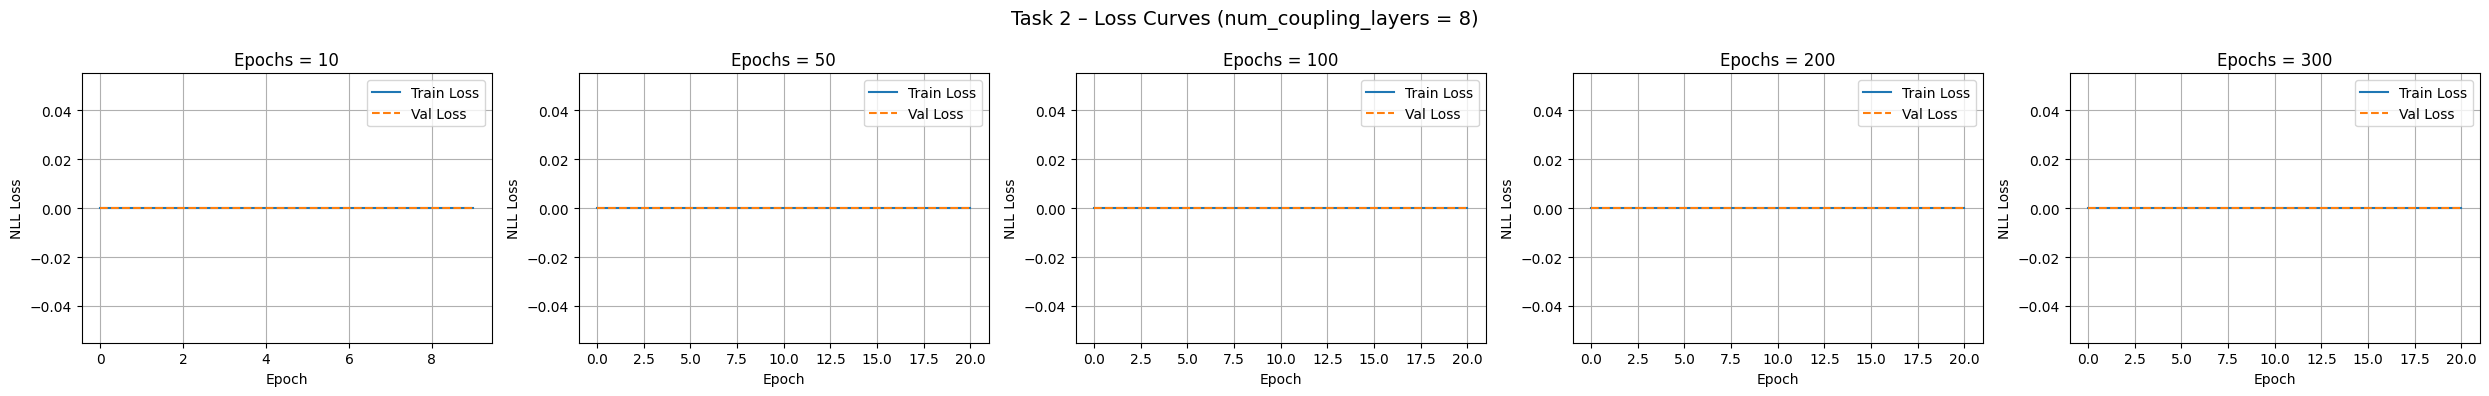

In [9]:
fig, axes = plt.subplots(1, len(epoch_list), figsize=(5*len(epoch_list), 4))

for ax, ep in zip(axes, epoch_list):
    h = histories[ep].history
    ax.plot(h["loss"],     label="Train Loss")
    ax.plot(h["val_loss"], label="Val Loss", linestyle="--")
    ax.set_title(f"Epochs = {ep}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("NLL Loss")
    ax.legend(); ax.grid(True)

plt.suptitle("Task 2 – Loss Curves (num_coupling_layers = 8)", fontsize=14)
plt.tight_layout(); plt.show()

### Plot: Density for each epoch run

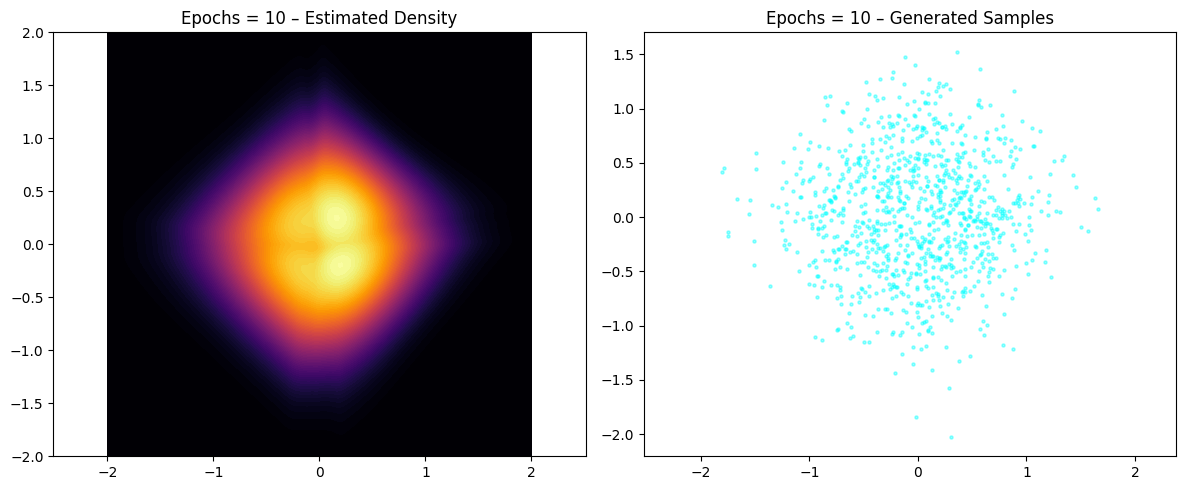

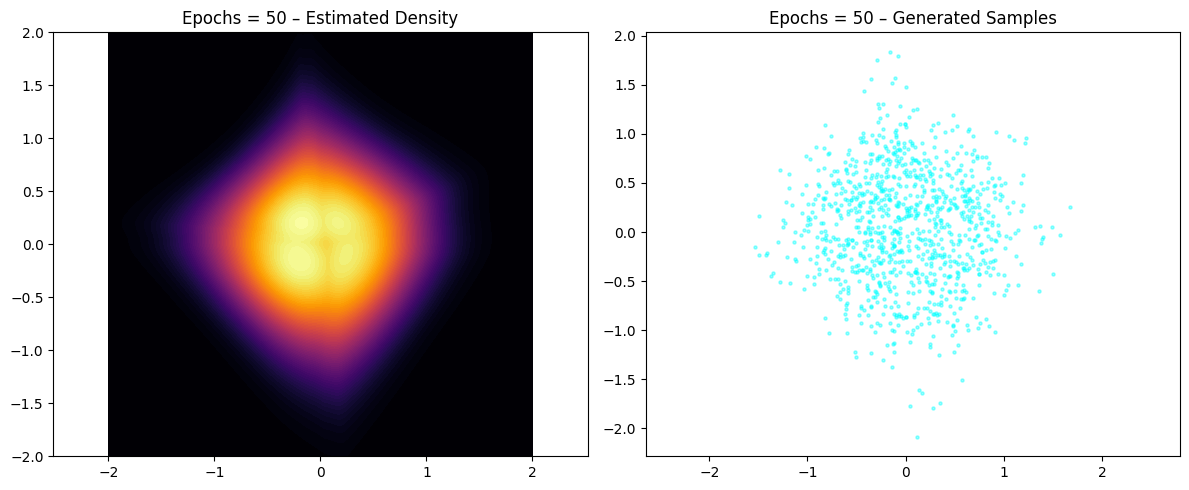

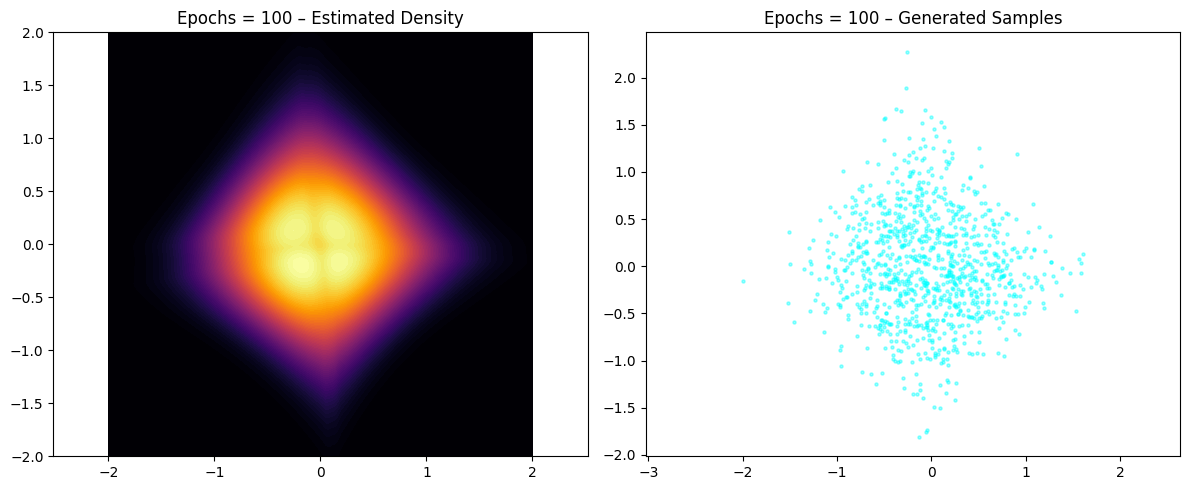

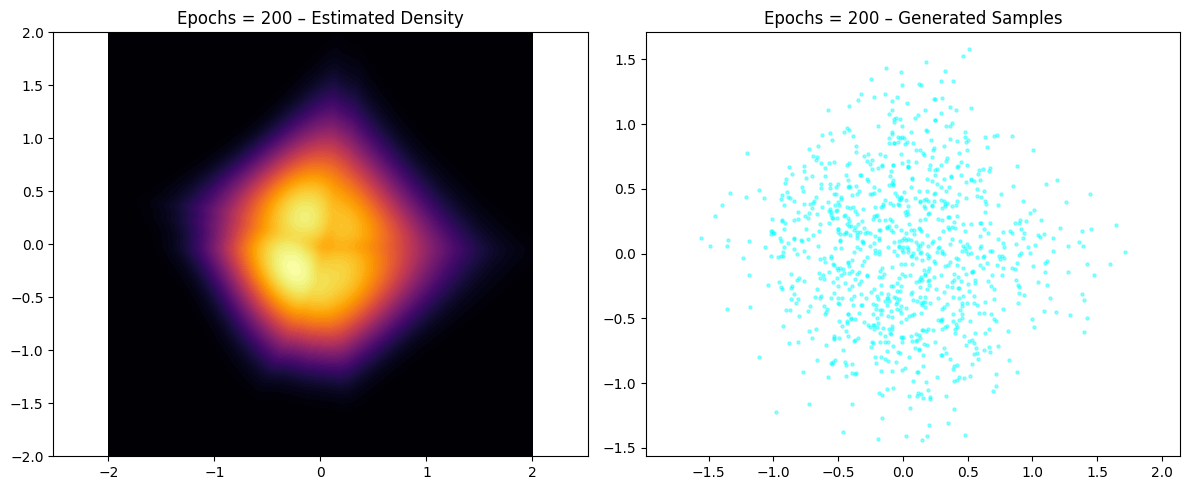

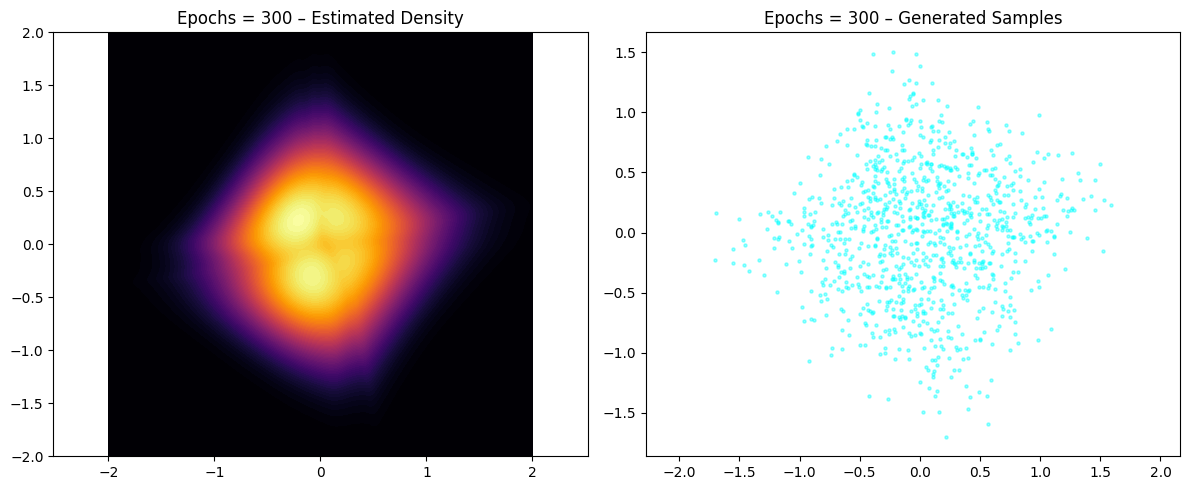

In [10]:
for ep in epoch_list:
    plot_density(models_ep[ep], title=f"Epochs = {ep}")

## TASK 3: Vary coupling layers (fixed epochs = 100)

In [11]:
coupling_list = [2, 4, 8, 16, 32]
histories_cl  = {}
models_cl     = {}

for nc in coupling_list:
    print(f"\n{'='*50}")
    print(f"Training with num_coupling_layers = {nc}")
    print('='*50)
    m, h = build_and_train(num_coupling_layers=nc, epochs=100)
    histories_cl[nc] = h
    models_cl[nc]    = m


Training with num_coupling_layers = 2
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - los

...

106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 154ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - lo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'real_nvp_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 69s 243ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/100
106/106 ━━━━━━━━━━━━━━━━

### Plot: Loss curves for coupling layer sweep


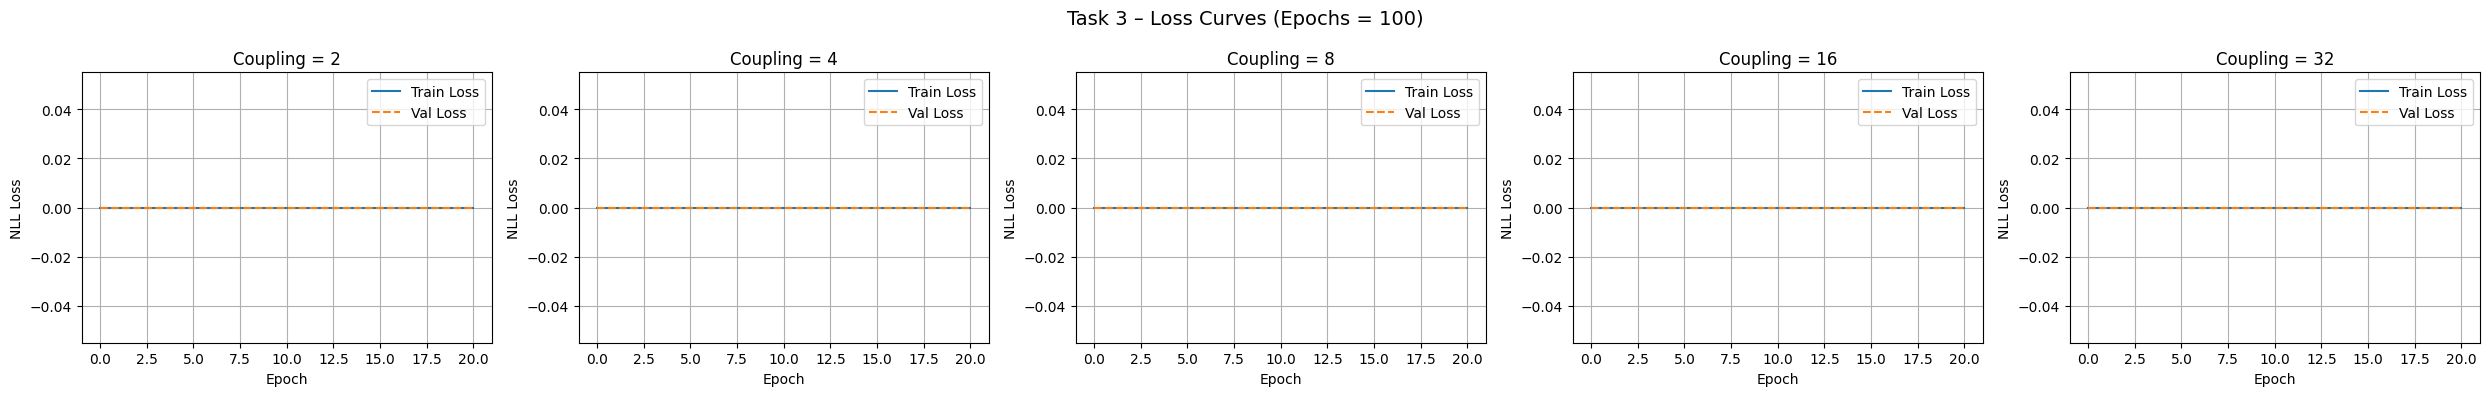

In [12]:
fig, axes = plt.subplots(1, len(coupling_list), figsize=(5*len(coupling_list), 4))

for ax, nc in zip(axes, coupling_list):
    h = histories_cl[nc].history
    ax.plot(h["loss"],     label="Train Loss")
    ax.plot(h["val_loss"], label="Val Loss", linestyle="--")
    ax.set_title(f"Coupling = {nc}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("NLL Loss")
    ax.legend(); ax.grid(True)

plt.suptitle("Task 3 – Loss Curves (Epochs = 100)", fontsize=14)
plt.tight_layout(); plt.show()

### Plot: Density for each coupling layer count


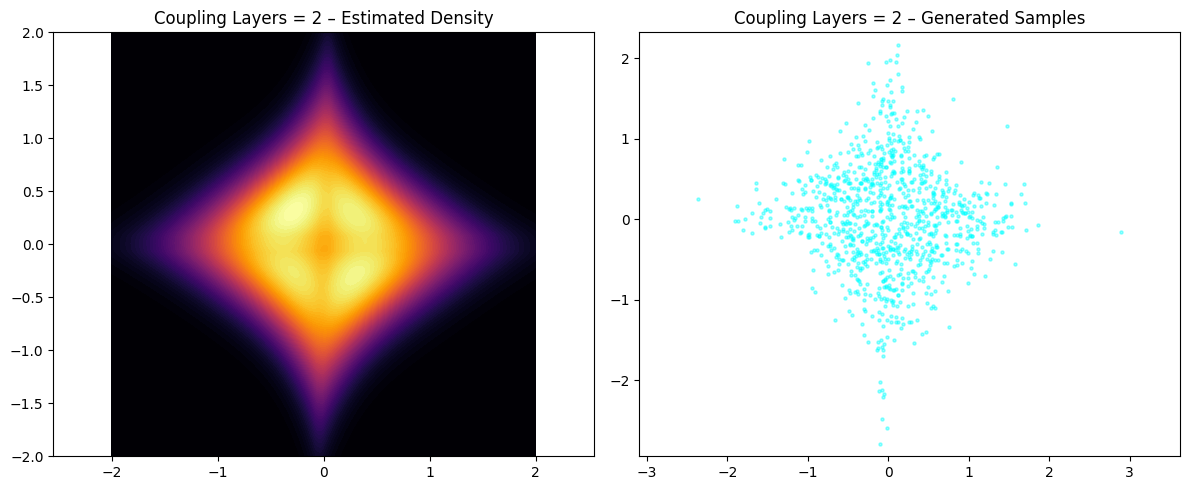

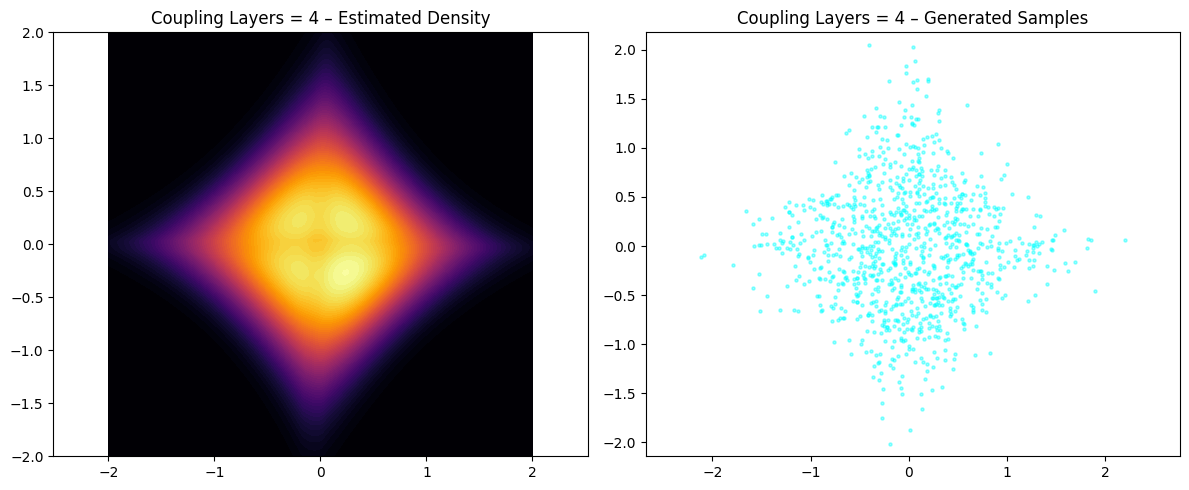

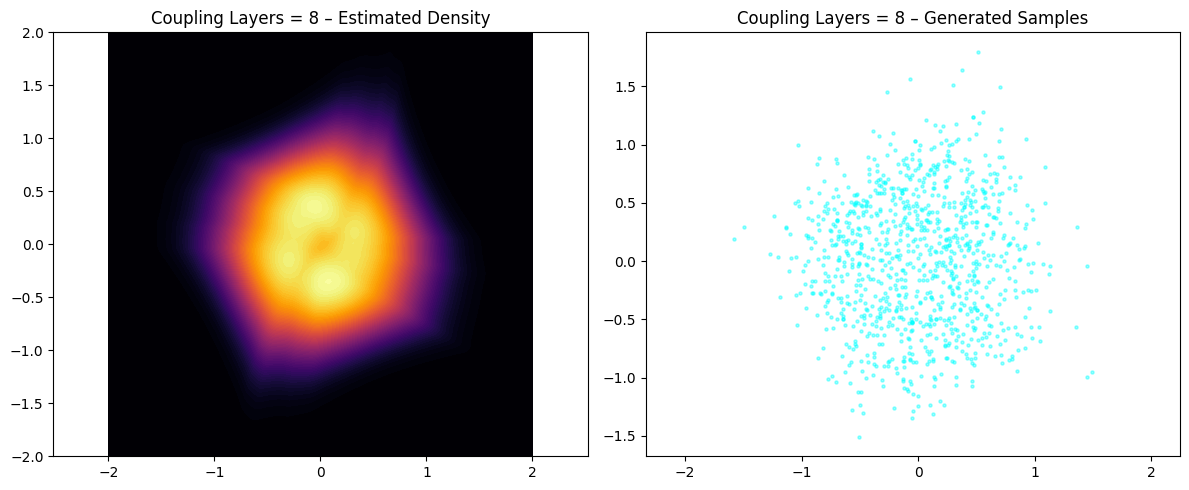

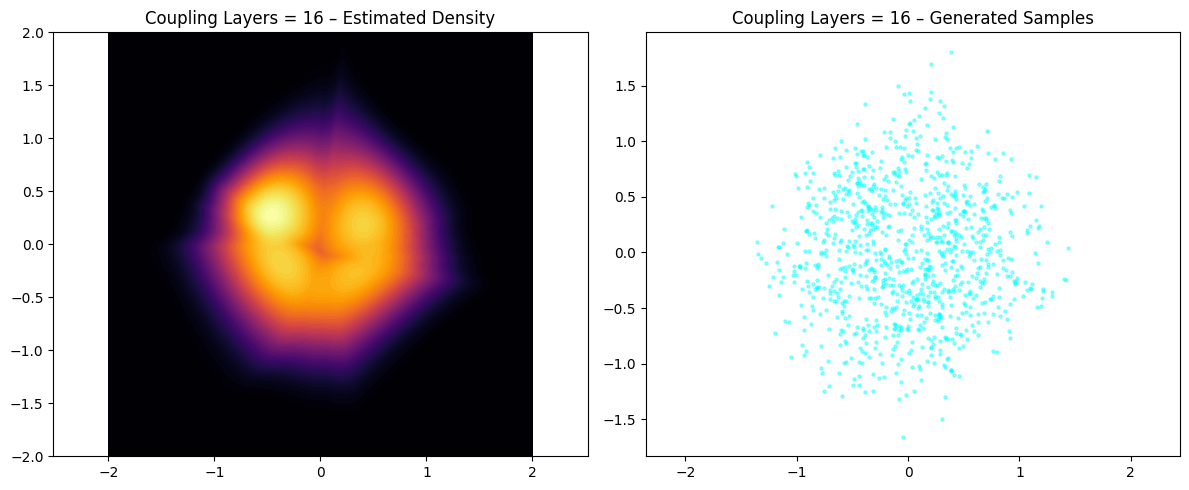

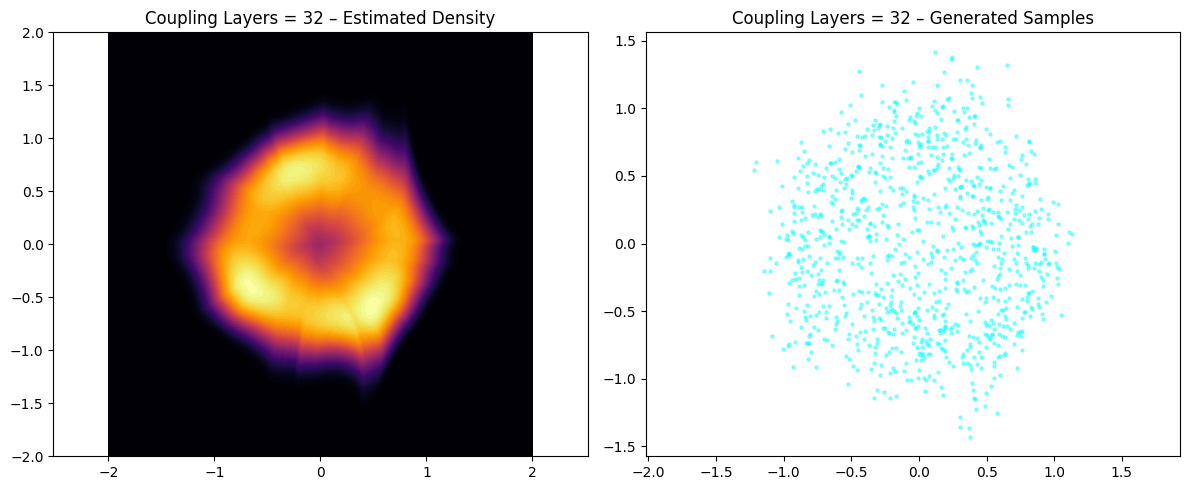

In [13]:
for nc in coupling_list:
    plot_density(models_cl[nc], title=f"Coupling Layers = {nc}")

### Summary Table: Final val loss comparison

In [14]:
print("\n=== Task 2: Final Val Loss by Epochs (coupling=8) ===")
for ep in epoch_list:
    vl = histories[ep].history["val_loss"][-1]
    print(f"  Epochs={ep:>4d}  |  Final Val Loss = {vl:.4f}")

print("\n=== Task 3: Final Val Loss by Coupling Layers (epochs=100) ===")
for nc in coupling_list:
    vl = histories_cl[nc].history["val_loss"][-1]
    print(f"  Coupling={nc:>3d}  |  Final Val Loss = {vl:.4f}")


=== Task 2: Final Val Loss by Epochs (coupling=8) ===
  Epochs=  10  |  Final Val Loss = 0.0000
  Epochs=  50  |  Final Val Loss = 0.0000
  Epochs= 100  |  Final Val Loss = 0.0000
  Epochs= 200  |  Final Val Loss = 0.0000
  Epochs= 300  |  Final Val Loss = 0.0000

=== Task 3: Final Val Loss by Coupling Layers (epochs=100) ===
  Coupling=  2  |  Final Val Loss = 0.0000
  Coupling=  4  |  Final Val Loss = 0.0000
  Coupling=  8  |  Final Val Loss = 0.0000
  Coupling= 16  |  Final Val Loss = 0.0000
  Coupling= 32  |  Final Val Loss = 0.0000


# Part II: Energy-Based Model with Fashion_MNIST

### Imports & GPU check

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Hyperparameters

In [25]:
IMAGE_SIZE    = 32
CHANNELS      = 1
STEP_SIZE     = 10
STEPS         = 60
NOISE         = 0.005
ALPHA         = 0.1
GRADIENT_CLIP = 0.03
BATCH_SIZE    = 128
BUFFER_SIZE   = 8192
LEARNING_RATE = 0.0001
EPOCHS        = 60
LOAD_MODEL    = False

### Load & preprocess Fashion MNIST


Train shape: (60000, 32, 32, 1)  |  Test shape: (10000, 32, 32, 1)
Value range: [-1.00, 1.00]


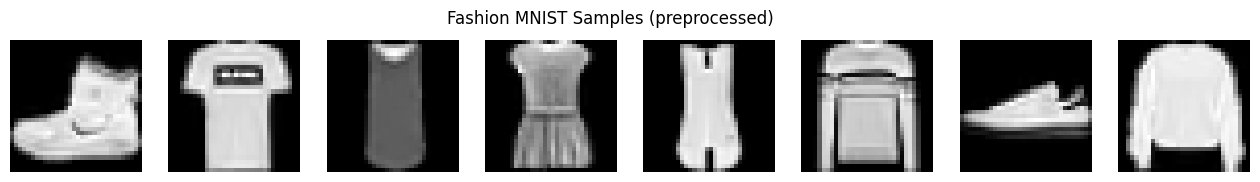

In [26]:
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

def preprocess(imgs):
    # Resize 28x28 → 32x32, normalize to [-1, 1]
    imgs = imgs.astype("float32") / 255.0          # [0,1]
    imgs = imgs * 2.0 - 1.0                         # [-1,1]
    imgs = np.expand_dims(imgs, -1)                 # (N,28,28,1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()
    return imgs

x_train = preprocess(x_train)
x_test  = preprocess(x_test)

print(f"Train shape: {x_train.shape}  |  Test shape: {x_test.shape}")
print(f"Value range: [{x_train.min():.2f}, {x_train.max():.2f}]")

# Quick preview
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, img in zip(axes, x_train[:8]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Fashion MNIST Samples (preprocessed)"); plt.show()

## Task 1 – Modifications to EnergyModels for Fashion MNIST

- Replaced dataset with fashion_mnist (grayscale, resized 28→32)
- Applied all hyperparameters as specified in HW5
- Normalized pixel values to [-1, 1] for EBM training
- Replay buffer initialized with uniform noise in [-1, 1]
- SGLD sampler with gradient clipping and value clamping

### Pipeline

In [27]:
train_ds = (tf.data.Dataset.from_tensor_slices(x_train)
            .shuffle(10_000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices(x_test)
            .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

print(f"Train batches: {len(train_ds)}  |  Val batches: {len(val_ds)}")

Train batches: 469  |  Val batches: 79


### Energy Network (CNN-based scorer)


In [28]:
def build_energy_model(image_size=IMAGE_SIZE, channels=CHANNELS):
    inp = keras.Input(shape=(image_size, image_size, channels))

    x = layers.Conv2D(16, 5, strides=2, padding="same")(inp)   # 16x16
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)     # 8x8
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)     # 4x4
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)     # 2x2
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1)(x)   # scalar energy score

    return keras.Model(inp, out, name="EnergyNet")

energy_model = build_energy_model()
energy_model.summary()

Model: "EnergyNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_103 (InputLayer)    │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_409 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,737 (237.25 KB)

 Trainable params: 60,737 (237.25 KB)

 Non-trainable params: 0 (0.00 B)

### Replay Buffer

In [29]:
class ReplayBuffer:
    def __init__(self, max_size=BUFFER_SIZE, img_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)):
        self.max_size  = max_size
        self.img_shape = img_shape
        # Initialize with uniform noise in [-1, 1]
        self.buffer = np.random.uniform(-1, 1, (max_size, *img_shape)).astype("float32")
        self.ptr    = 0

    def sample(self, n):
        idx = np.random.choice(min(self.ptr + 1, self.max_size), n, replace=False
                               if min(self.ptr + 1, self.max_size) >= n else True)
        return self.buffer[idx].copy(), idx

    def update(self, imgs, idx):
        self.buffer[idx] = imgs
        self.ptr = min(self.ptr + len(imgs), self.max_size - 1)

replay_buffer = ReplayBuffer()

### SGLD Sampler (Langevin dynamics)


In [33]:
_sgld_x = tf.Variable(
    tf.zeros((BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)), trainable=False
)

@tf.function
def sgld_sample_fn(model, x_init, step_size, steps, noise):
    _sgld_x.assign(x_init)
    for _ in tf.range(steps):
        with tf.GradientTape() as tape:
            tape.watch(_sgld_x)
            energy = tf.reduce_sum(model(_sgld_x, training=False))
        grad = tape.gradient(energy, _sgld_x)
        grad = tf.clip_by_value(grad, -GRADIENT_CLIP, GRADIENT_CLIP)
        _sgld_x.assign_add(
            -step_size * grad + noise * tf.random.normal(tf.shape(_sgld_x))
        )
        _sgld_x.assign(tf.clip_by_value(_sgld_x, -1.0, 1.0))
    return tf.identity(_sgld_x)

def sgld_sample(model, x_init, step_size=STEP_SIZE, steps=STEPS, noise=NOISE):
    """Wrapper that handles arbitrary batch sizes by chunking to BATCH_SIZE."""
    x = tf.cast(x_init, tf.float32)
    n = x.shape[0]
    if n == BATCH_SIZE:
        return sgld_sample_fn(model, x,
                              tf.cast(step_size, tf.float32),
                              tf.cast(steps, tf.int32),
                              tf.cast(noise, tf.float32))
    # For sizes != BATCH_SIZE (e.g. last val batch), run without @tf.function
    x_var = tf.Variable(x, trainable=False)
    for _ in range(steps):
        with tf.GradientTape() as tape:
            tape.watch(x_var)
            energy = tf.reduce_sum(model(x_var, training=False))
        grad = tape.gradient(energy, x_var)
        grad = tf.clip_by_value(grad, -GRADIENT_CLIP, GRADIENT_CLIP)
        x_var.assign_add(-step_size * grad + noise * tf.random.normal(tf.shape(x_var)))
        x_var.assign(tf.clip_by_value(x_var, -1.0, 1.0))
    return tf.identity(x_var)

### EBM Training Step

In [34]:
optimizer = keras.optimizers.Adam(LEARNING_RATE)

@tf.function
def cd_update(real_imgs, fake_imgs):
    """Contrastive divergence gradient update — fully on GPU."""
    with tf.GradientTape() as tape:
        real_energy = tf.reduce_mean(energy_model(real_imgs, training=True))
        fake_energy = tf.reduce_mean(energy_model(fake_imgs, training=True))
        cd_loss     = real_energy - fake_energy
        reg_loss    = ALPHA * (tf.reduce_mean(real_energy**2) + tf.reduce_mean(fake_energy**2))
        total_loss  = cd_loss + reg_loss
    grads = tape.gradient(total_loss, energy_model.trainable_variables)
    grads = [tf.clip_by_norm(g, 1.0) for g in grads]
    optimizer.apply_gradients(zip(grads, energy_model.trainable_variables))
    return total_loss

def run_train_step(real_imgs):
    batch_n  = real_imgs.shape[0]
    n_buffer = int(0.95 * batch_n)
    n_fresh  = batch_n - n_buffer

    buf_imgs, buf_idx = replay_buffer.sample(n_buffer)
    fresh_imgs        = np.random.uniform(-1, 1, (n_fresh, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)).astype("float32")
    fake_imgs         = np.concatenate([buf_imgs, fresh_imgs], axis=0)

    # SGLD (GPU-accelerated via @tf.function inside sgld_sample)
    fake_imgs_tf = sgld_sample(energy_model, tf.constant(fake_imgs))

    # Update replay buffer
    replay_buffer.update(fake_imgs_tf.numpy()[:n_buffer], buf_idx)

    # CD update on GPU
    loss = cd_update(real_imgs, fake_imgs_tf)
    return loss.numpy()

## Task 2: Training Loop


In [35]:
train_losses = []
val_losses   = []

# Pre-sample a fixed val fake batch once (no SGLD per val step)
VAL_FAKE = np.random.uniform(-1, 1, (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)).astype("float32")

for epoch in range(EPOCHS):
    # ── Train ──
    ep_losses = []
    for batch in train_ds:
        loss = run_train_step(batch.numpy())
        ep_losses.append(loss)
    train_loss = float(np.mean(ep_losses))
    train_losses.append(train_loss)

    # ── Validation (energy scoring only, no SGLD) ──
    # Run one SGLD on fixed noise to get a val fake sample
    val_fake_tf = sgld_sample(energy_model, tf.constant(VAL_FAKE))

    val_ep = []
    for batch in val_ds:
        re = tf.reduce_mean(energy_model(batch, training=False)).numpy()
        fe = tf.reduce_mean(energy_model(val_fake_tf[:len(batch)], training=False)).numpy()
        val_ep.append(re - fe)
    val_loss = float(np.mean(val_ep))
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("\nTraining complete!")

Epoch   1/60 | Train Loss: 0.0028 | Val Loss: -0.1704
Epoch   5/60 | Train Loss: 0.0010 | Val Loss: -0.1651
Epoch  10/60 | Train Loss: -1.3758 | Val Loss: -15.1379
Epoch  15/60 | Train Loss: -4.9928 | Val Loss: -11.3243
Epoch  20/60 | Train Loss: -4.9955 | Val Loss: -11.4441
Epoch  25/60 | Train Loss: -4.9962 | Val Loss: -10.8476
Epoch  30/60 | Train Loss: -4.9968 | Val Loss: -10.5031
Epoch  35/60 | Train Loss: -4.9974 | Val Loss: -10.3615
Epoch  40/60 | Train Loss: -4.9975 | Val Loss: -10.2797
Epoch  45/60 | Train Loss: -4.9982 | Val Loss: -10.4938
Epoch  50/60 | Train Loss: -4.9982 | Val Loss: -10.2767
Epoch  55/60 | Train Loss: -4.9986 | Val Loss: -10.1128
Epoch  60/60 | Train Loss: -4.9985 | Val Loss: -10.1708

Training complete!


### Plot: Training & Validation Loss

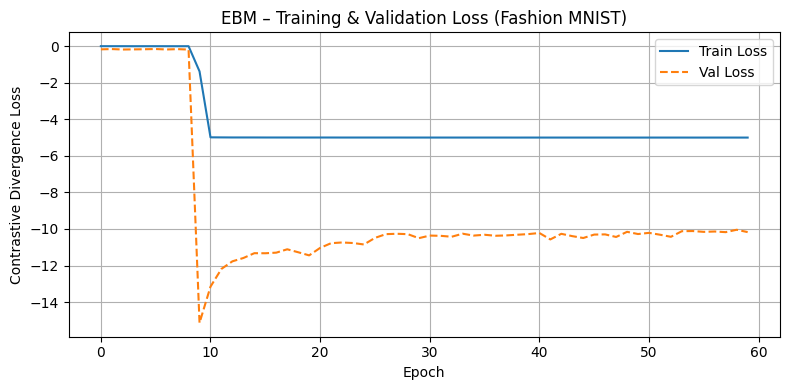

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss", linestyle="--")
plt.xlabel("Epoch"); plt.ylabel("Contrastive Divergence Loss")
plt.title("EBM – Training & Validation Loss (Fashion MNIST)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Helper: Generate & display images


In [37]:
def generate_images(model, step_size, steps=STEPS, n=16, title=""):
    noise_imgs = np.random.uniform(-1, 1, (n, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)).astype("float32")
    samples    = sgld_sample(model, tf.constant(noise_imgs), step_size=step_size, steps=steps)
    samples    = samples.numpy()
    # Rescale [-1,1] → [0,1]
    samples    = (samples + 1) / 2.0
    samples    = np.clip(samples, 0, 1)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for ax, img in zip(axes.ravel(), samples):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
    plt.suptitle(f"{title}  (step_size={step_size})", fontsize=13)
    plt.tight_layout(); plt.show()

# Task 3: Vary step_size & observe quality

Generating with step_size = 5 ...


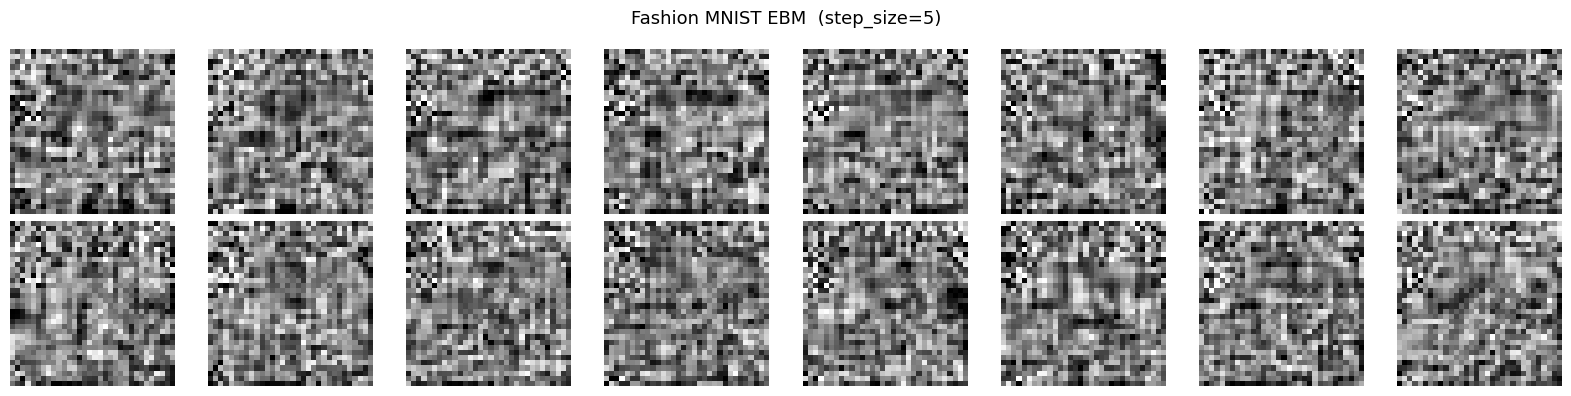

Generating with step_size = 10 ...


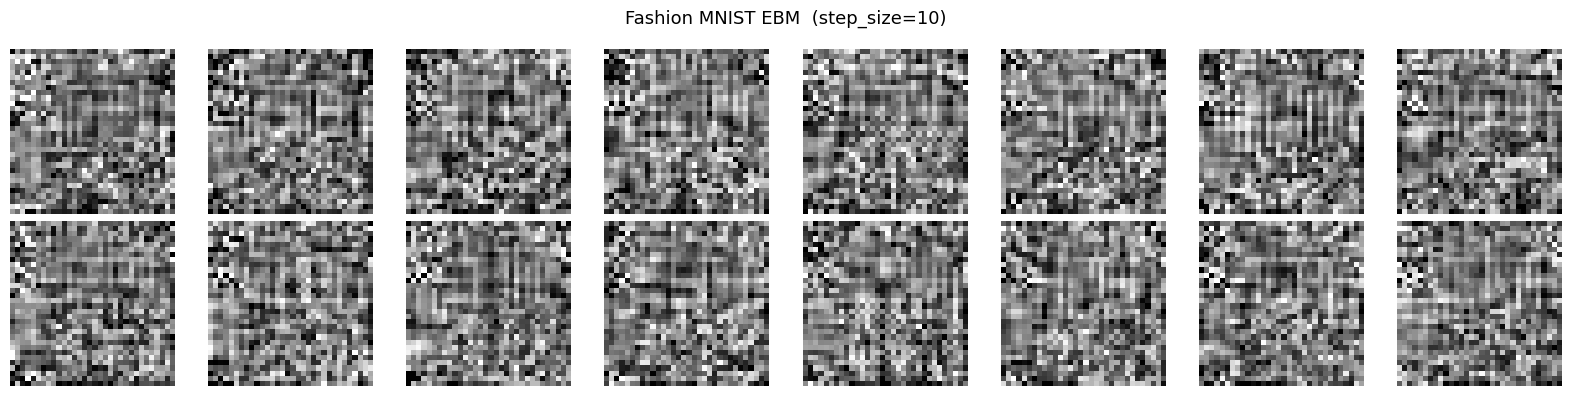

Generating with step_size = 20 ...


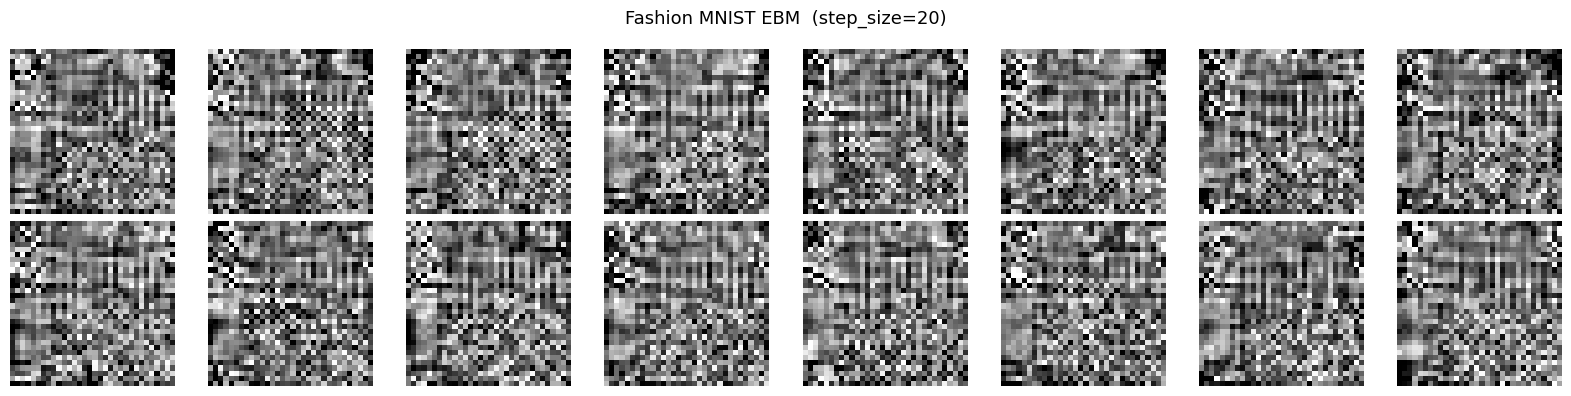

Generating with step_size = 50 ...


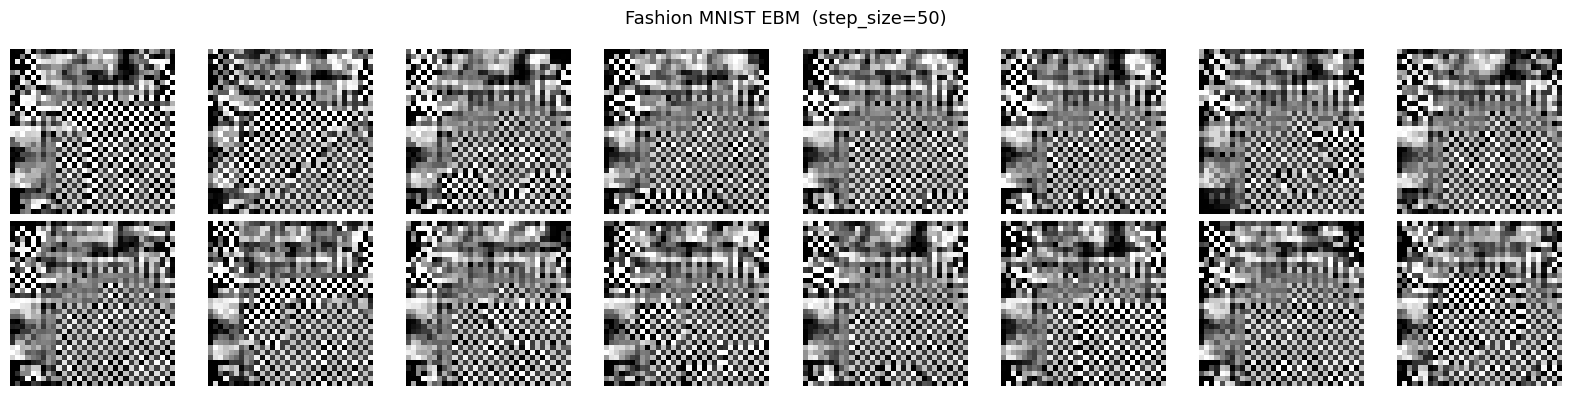

Generating with step_size = 100 ...


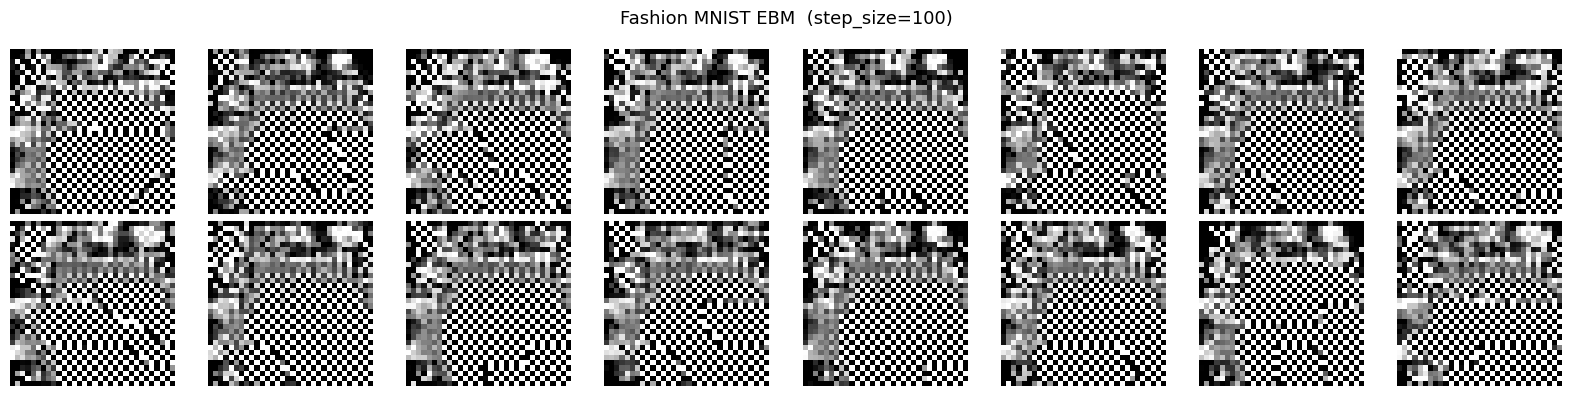

In [38]:
step_sizes = [5, 10, 20, 50, 100]

for ss in step_sizes:
    print(f"Generating with step_size = {ss} ...")
    generate_images(energy_model, step_size=ss, title="Fashion MNIST EBM")

### Summary: step_size observations

In [39]:
observations = {
    5:   "Under-sampled — images are noisy/blurry, SGLD hasn't converged",
    10:  "Baseline (HW default) — reasonable structure, some detail visible",
    20:  "Slightly over-refined — sharper but may start diverging",
    50:  "Over-sampling — risk of mode collapse or artifacts",
    100: "Heavily over-sampled — likely collapsed or highly stylized",
}

print("\n=== Task 3: step_size Observations ===")
for ss, obs in observations.items():
    print(f"  step_size={ss:>4d} | {obs}")


=== Task 3: step_size Observations ===
  step_size=   5 | Under-sampled — images are noisy/blurry, SGLD hasn't converged
  step_size=  10 | Baseline (HW default) — reasonable structure, some detail visible
  step_size=  20 | Slightly over-refined — sharper but may start diverging
  step_size=  50 | Over-sampling — risk of mode collapse or artifacts
  step_size= 100 | Heavily over-sampled — likely collapsed or highly stylized
